In [1]:
from plotting import *
from data_processing import *

In [ ]:
INPUT_DATA_PATH = "../parsed_data"
OUTPUT_DATA_PATH = "/plots"

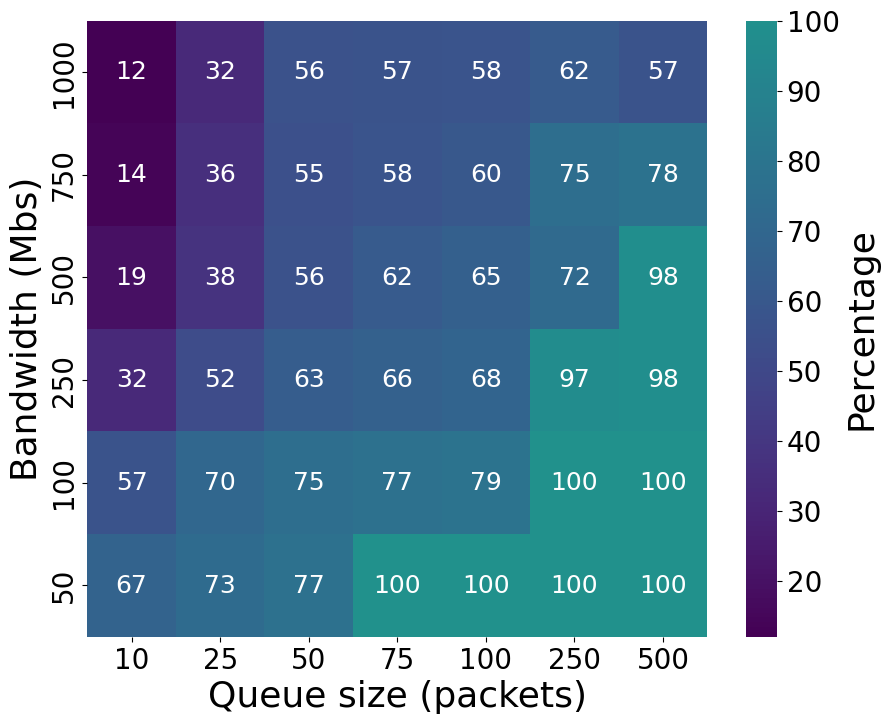

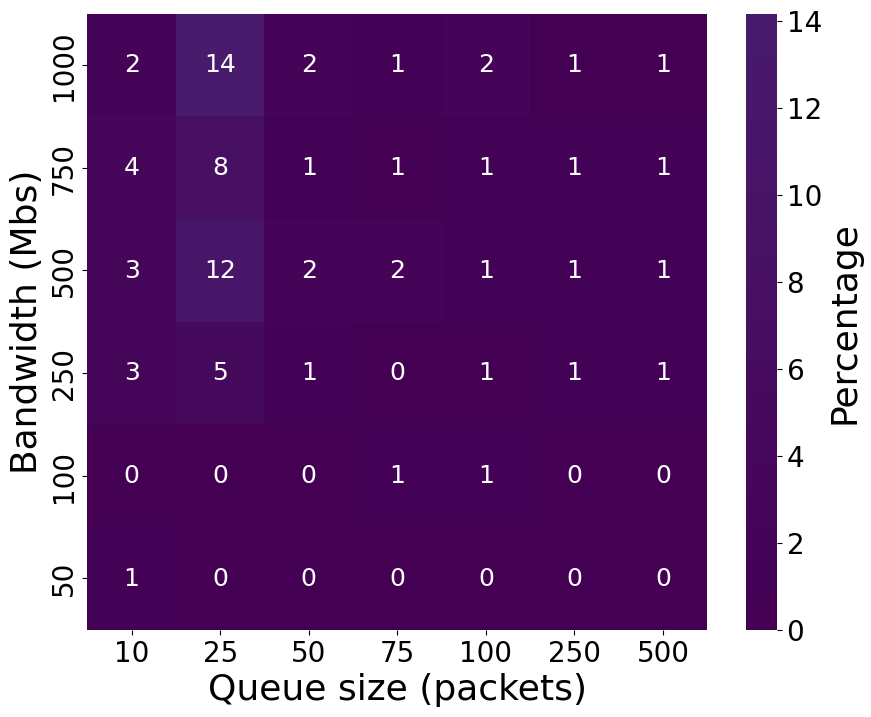

In [10]:
import numpy as np

bandwidths = [50, 100, 250, 500, 750, 1000]
queues = [10, 25, 50, 75, 100, 250, 500]

aggregate = transform_to_2d_matrix(f"{INPUT_DATA_PATH}/exp_20260308-114727_inflight-default-tso-off-combined-1.txt", 10)
statistics = get_statistics(aggregate)

mean_values = transform_to_matrix_of_metric(statistics.iloc[:, 0].tolist(), bandwidths, queues)
stddev_values = transform_to_matrix_of_metric(statistics.iloc[:, 1].tolist(), bandwidths, queues)

stddev_percentage = stddev_values.div(mean_values).mul(100)
stddev_percentage = stddev_percentage.replace([np.inf, -np.inf], 0).fillna(0)

percentage = get_as_percentage_matrix(mean_values, bandwidths, queues, 30).round().astype(int)
percentage = percentage.clip(upper=100)
plot_heatmap(percentage, "heatmap mean max flight one queue default pacing", OUTPUT_DATA_PATH)
plot_heatmap_stddev(stddev_percentage, "heatmap stddev max flight one queue default pacing", OUTPUT_DATA_PATH)